In [11]:
import fitz  # PyMuPDF
from PIL import Image
import io

def pdf_to_images_in_memory(pdf_path):
    """
    Reads a PDF file and creates an in-memory PIL Image object for each page.

    Args:
        pdf_path (str): The file path to the PDF.

    Returns:
        list: A list of PIL Image objects, or an empty list if an error occurs.
    """
    try:
        # Open the PDF file
        doc = fitz.open(pdf_path)
    except Exception as e:
        print(f"Error opening PDF file: {e}")
        return []

    images = []
    # Iterate through each page of the PDF
    for page_num in range(len(doc)):
        # Get the page
        page = doc.load_page(page_num)
        
        # Render the page to a pixmap (an image format in PyMuPDF)
        pix = page.get_pixmap()
        
        # Get the image data as bytes
        img_data = pix.tobytes("png")
        
        # Create a PIL Image from the data
        image = Image.open(io.BytesIO(img_data))
        
        # Append the image to the list
        images.append(image)
        
    # Close the document
    doc.close()
    
    return images

In [12]:
pdf_path = 'files/pdfs/17116353_Rihanna_31-01-2025_10.52.27.355_AM.pdf'  # Replace 'your_file.pdf' with the actual PDF file name
pdf_file = pdf_to_images_in_memory(pdf_path)


Number of images extracted: 2


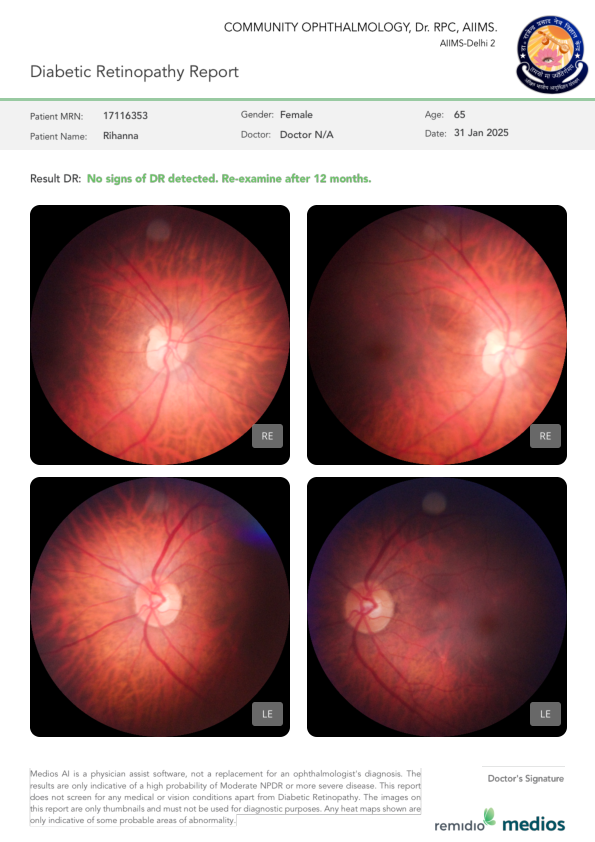

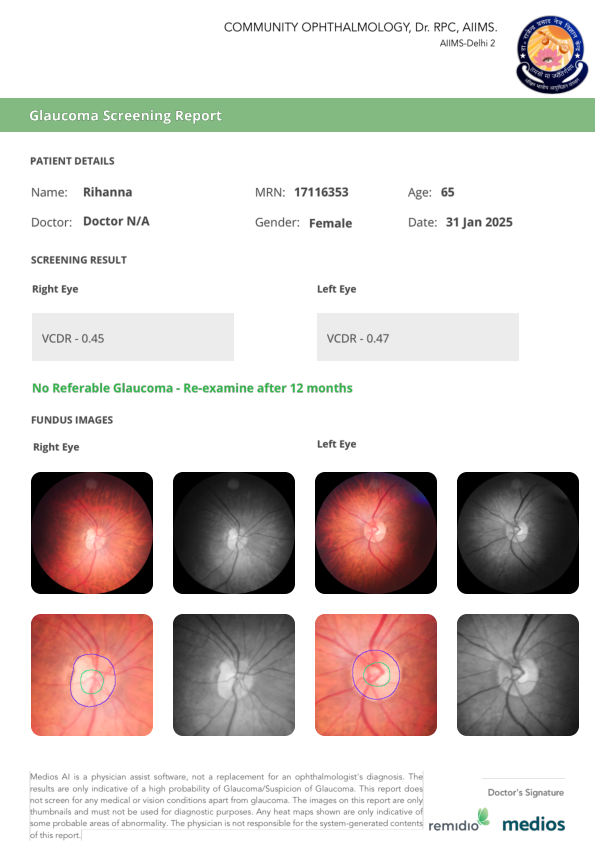

In [13]:
print(f"Number of images extracted: {len(pdf_file)}")
for img in pdf_file:
    display(img)
    # img.show()  # Uncomment to display each image in a window
    

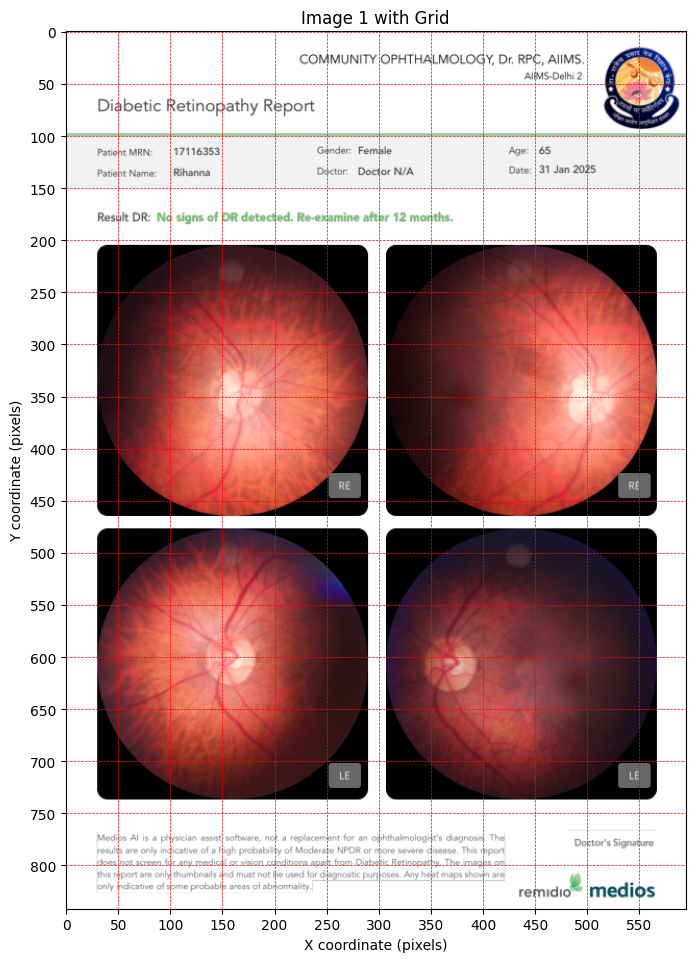

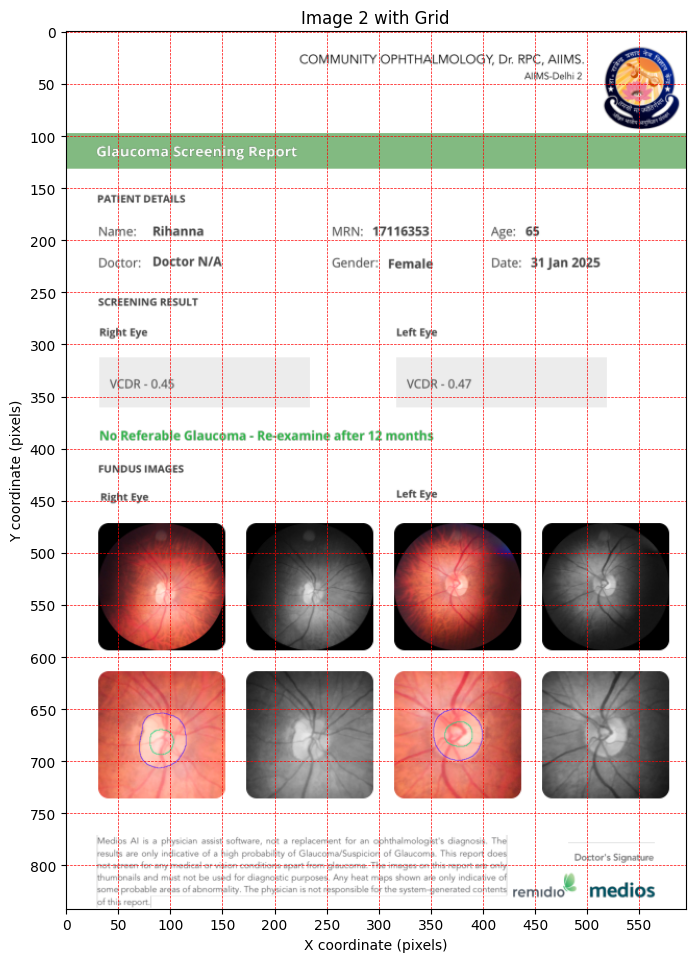

In [14]:
import matplotlib.pyplot as plt

for idx, image in enumerate(pdf_file):
    plt.figure(figsize=(8, 12))
    plt.imshow(image)
    plt.title(f"Image {idx+1} with Grid")
    plt.grid(True, which='both', color='red', linestyle='--', linewidth=0.5)
    plt.xticks(range(0, image.width, 50))
    plt.yticks(range(0, image.height, 50))
    plt.xlabel('X coordinate (pixels)')
    plt.ylabel('Y coordinate (pixels)')
    plt.show()

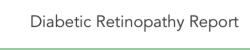

Does page 1 image contain "Diabetic" at the specified coordinates? True
Extracted text: diabetic retinopathy report



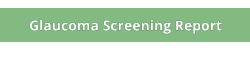

Extracted text: glaucoma screening report

Does page  image contain "Glaucoma" at the specified coordinates? True


In [ ]:
import pytesseract

# Check if "Diabetic" is present
region = pdf_file[0].crop((0, 50, 250, 100))  # y2 = y1 + some height, e.g., 50 pixels
display(region)
text = pytesseract.image_to_string(region).lower()
contains_diabetic = "diabetic" in text
print(f'Does page 1 image contain "Diabetic" at the specified coordinates? {contains_diabetic}')
print("Extracted text:", text)


# Check if "Glaucoma" is present
region2 = pdf_file[1].crop((0, 90, 250, 150))  # y2 = y1 + some height, e.g., 50 pixels
display(region2)
text2 = pytesseract.image_to_string(region2).lower()
print("Extracted text:", text2)
contains_glaucoma = "glaucoma" in text2
print(f'Does page  image contain "Glaucoma" at the specified coordinates? {contains_glaucoma}')